# Physics-Informed Neural Network for sin(x)

This notebook:
- Solves y'' + y = 0 using PINNs
- Studies noisy boundary conditions
- Compares activations
- Diagnoses overfitting

In [ ]:
import sys
import math
import numpy as np
from tqdm import tqdm

# --- plotting ---
import matplotlib
import matplotlib.pyplot as plt
import pylab as py
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
from matplotlib import colors
import matplotlib.gridspec as gridspec
from IPython.display import display, clear_output

# --- torch ---
import torch
import torch.nn as nn
import torch.distributions as dist
from torch.optim.lr_scheduler import CosineAnnealingLR

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Default dtype + device
# -----------------------------
torch.set_default_dtype(torch.float64)

ngpu = 1
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
print("Device:", device)
print("Default dtype:", torch.get_default_dtype())

Device: cpu
Default dtype: torch.float64


In [ ]:
# ======================================================
# Cell 2 — Plotting Utilities & Defaults
# ======================================================

# Global matplotlib style (safe for APS-style figures)
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "lines.linewidth": 2,
})

# ------------------------------------------------------
# Helper: plot training loss
# ------------------------------------------------------
def plot_loss(losses, log_scale=True, xlabel="Epoch", ylabel="Loss"):
    plt.figure(figsize=(6, 4))
    plt.plot(losses)
    if log_scale:
        plt.yscale("log")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------
# Helper: plot NN / PINN solution vs truth
# ------------------------------------------------------
def plot_solution(
    x,
    y_pred,
    y_true=None,
    x_bc=None,
    y_bc=None,
    train_domain=None,
    labels=("Model", "True"),
    title=None,
    xlim=None,
):
    plt.figure(figsize=(10, 4))

    # model prediction
    plt.plot(x, y_pred, 'r', label=labels[0])

    # true solution
    if y_true is not None:
        plt.plot(x, y_true, 'b--', label=labels[1])

    # boundary / observation points
    if x_bc is not None and y_bc is not None:
        plt.scatter(x_bc, y_bc, s=40, zorder=5, label="Boundary conditions")

    # training domain shading
    if train_domain is not None:
        a, b = train_domain
        plt.axvspan(a, b, alpha=0.12, label=f"Training domain [{a:.2f}, {b:.2f}]")

    if title:
        plt.title(title)

    plt.xlabel("x")
    plt.ylabel("y")
    if xlim is not None:
        plt.xlim(xlim)

    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------
# Helper: save current figure safely
# ------------------------------------------------------
def savefig(filename):
    py.savefig(filename, bbox_inches="tight")
    print(f"Saved figure -> {filename}")


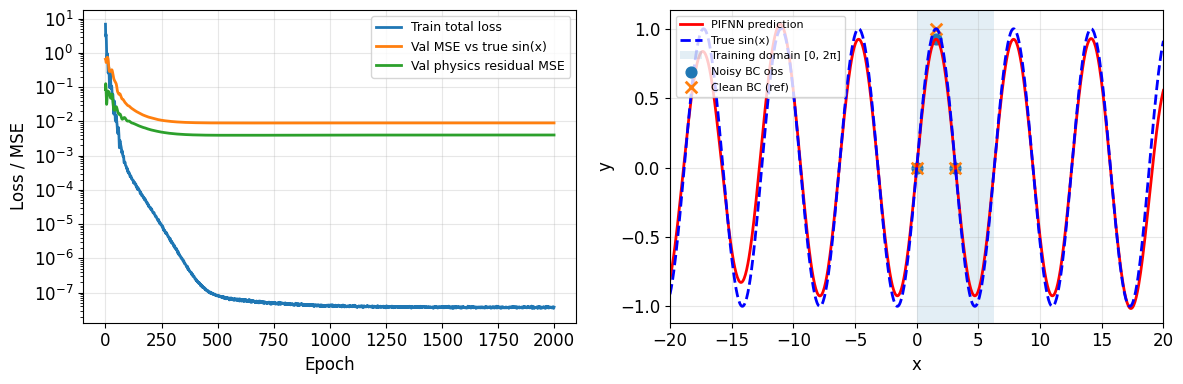

In [ ]:
# ======================================================
# Cell 3 — PINN/PIFNN setup + NOISY BCs + Validation diagnostics (no DataLoaders)
# ======================================================

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pylab as py
from torch.optim.lr_scheduler import CosineAnnealingLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Controls
# -----------------------------
n_epochs = 2000
n_collocation = 1000
lr = 0.04
bc_weight = 10.0
use_scheduler = True

# noise on BC observations (synthetic noisy measurements)
bc_noise_level = 0.10

# validation domain (outside training)
val_left, val_right = -20.0, 20.0
n_val = 800

# plotting cadence
plot_every = 200

# -----------------------------
# Cosine activation module
# -----------------------------
class CosineActivation(nn.Module):
    def forward(self, x):
        return torch.cos(x)

# -----------------------------
# Model
# -----------------------------
class NN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        net = []
        for i in range(len(layers) - 1):
            net.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                net.append(CosineActivation())
        self.model = nn.Sequential(*net)

    def forward(self, x):
        return self.model(x)

# -----------------------------
# ODE residual: u'' + u = 0
# -----------------------------
def ode_residual(model, x, y):
    dy_dx = torch.autograd.grad(y, x, torch.ones_like(y), create_graph=True)[0]
    d2y_dx2 = torch.autograd.grad(dy_dx, x, torch.ones_like(dy_dx), create_graph=True)[0]
    return d2y_dx2 + y

# -----------------------------
# Periodicity loss (PIFNN)
# -----------------------------
def periodic_loss_fn(model, x):
    period = 2 * torch.pi
    bc1 = model(x - period) - model(x)
    bc2 = model(x + period) - model(x)
    return (bc1**2) + (bc2**2)

# -----------------------------
# Build model
# -----------------------------
layers = [1, 20, 1]
model = NN(layers).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
if use_scheduler:
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs)

# -----------------------------
# Boundary conditions + noise (keep x clean, add noise to y only)
# -----------------------------
x_bc = torch.tensor([0.0, float(torch.pi/2), float(torch.pi)], device=device).view(-1, 1)
y_bc_clean = torch.sin(x_bc)
y_bc = y_bc_clean + bc_noise_level * y_bc_clean * torch.randn_like(y_bc_clean)

# -----------------------------
# Validation grids (diagnostic only)
# -----------------------------
x_val = torch.linspace(val_left, val_right, n_val, device=device).view(-1, 1)
y_val_true = torch.sin(x_val)

# training domain shading
train_left = 0.0
train_right = float(2 * torch.pi)

# -----------------------------
# Logs
# -----------------------------
losses = []
val_data_mse = []     # MSE vs true sin(x) on validation grid
val_phys_mse = []     # mean residual^2 on validation grid

# ======================================================
# Training loop
# ======================================================
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()

    # Collocation points in [0, 2π]
    x_c = torch.rand(n_collocation, 1, device=device) * (2 * torch.pi)
    x_c.requires_grad_(True)

    y_c = model(x_c)

    # Physics loss
    residual_c = ode_residual(model, x_c, y_c)
    physics_loss = torch.mean(residual_c**2)

    # BC loss (noisy observations)
    pred_bc = model(x_bc)
    bc_loss = torch.mean((pred_bc - y_bc)**2)

    # Periodicity loss
    per_loss = torch.mean(periodic_loss_fn(model, x_c))

    # Total
    loss = physics_loss + bc_weight * bc_loss + per_loss
    loss.backward()
    optimizer.step()

    if use_scheduler:
        scheduler.step()

    losses.append(loss.item())

    # -----------------------------
    # Validation metrics (no grad)
    # -----------------------------
    model.eval()

    # Data MSE on validation grid (diagnostic)
    with torch.no_grad():
        y_val_pred = model(x_val)
        val_mse = torch.mean((y_val_pred - y_val_true)**2).item()
    val_data_mse.append(val_mse)

    # Physics residual on validation grid (needs autograd, but not optimizer)
    # We compute it with create_graph=False to keep it light.
    x_val_r = x_val.clone().detach().requires_grad_(True)
    y_val_r = model(x_val_r)
    r_val = ode_residual(model, x_val_r, y_val_r)
    val_r_mse = torch.mean(r_val**2).detach().item()
    val_phys_mse.append(val_r_mse)

    # -----------------------------
    # Live plot
    # -----------------------------
    if epoch % plot_every == 0 or epoch == n_epochs - 1:
        clear_output(wait=True)

        fig, ax = py.subplots(1, 2, figsize=(12, 4))

        # Losses (training total + validation diagnostics)
        ax[0].plot(losses, label="Train total loss")
        ax[0].plot(val_data_mse, label="Val MSE vs true sin(x)")
        ax[0].plot(val_phys_mse, label="Val physics residual MSE")
        ax[0].set_yscale("log")
        ax[0].set_xlabel("Epoch")
        ax[0].set_ylabel("Loss / MSE")
        ax[0].legend(loc="upper right", fontsize=9)

        # Solution on validation domain
        ax[1].plot(x_val.detach().cpu().numpy(), y_val_pred.detach().cpu().numpy(), "r", label="PIFNN prediction")
        ax[1].plot(x_val.detach().cpu().numpy(), y_val_true.detach().cpu().numpy(), "b--", label="True sin(x)")
        ax[1].axvspan(train_left, train_right, alpha=0.12, label="Training domain [0, 2π]")

        ax[1].scatter(x_bc.detach().cpu().numpy(), y_bc.detach().cpu().numpy(), s=60, label="Noisy BC obs")
        ax[1].scatter(x_bc.detach().cpu().numpy(), y_bc_clean.detach().cpu().numpy(), marker="x", s=70, label="Clean BC (ref)")

        ax[1].set_xlabel("x")
        ax[1].set_ylabel("y")
        ax[1].set_xlim(val_left, val_right)
        ax[1].legend(loc="upper left", fontsize=8)

        py.tight_layout()
        py.savefig("Cell3_PIFNN_with_validation.pdf", bbox_inches="tight")
        plt.show()


DataLoaders

DataLoaders are used to batch and efficiently sample:
Collocation points for enforcing the physics residual
Boundary condition points for supervised constraints
This improves training stability and enables scalable experiments.

Epoch     0 | loss/step 7.305e-02 | val MSE 2.799e-02
Epoch   200 | loss/step 1.922e-03 | val MSE 1.626e-02
Epoch   400 | loss/step 1.329e-06 | val MSE 6.610e-03
Epoch   600 | loss/step 4.210e-03 | val MSE 1.344e-02
Epoch   800 | loss/step 1.150e-06 | val MSE 2.828e-03
Epoch  1000 | loss/step 1.375e-07 | val MSE 2.813e-03
Epoch  1200 | loss/step 5.953e-07 | val MSE 2.867e-03
Epoch  1400 | loss/step 2.712e-07 | val MSE 2.881e-03
Epoch  1600 | loss/step 4.580e-06 | val MSE 2.816e-03
Epoch  1800 | loss/step 1.587e-08 | val MSE 2.801e-03


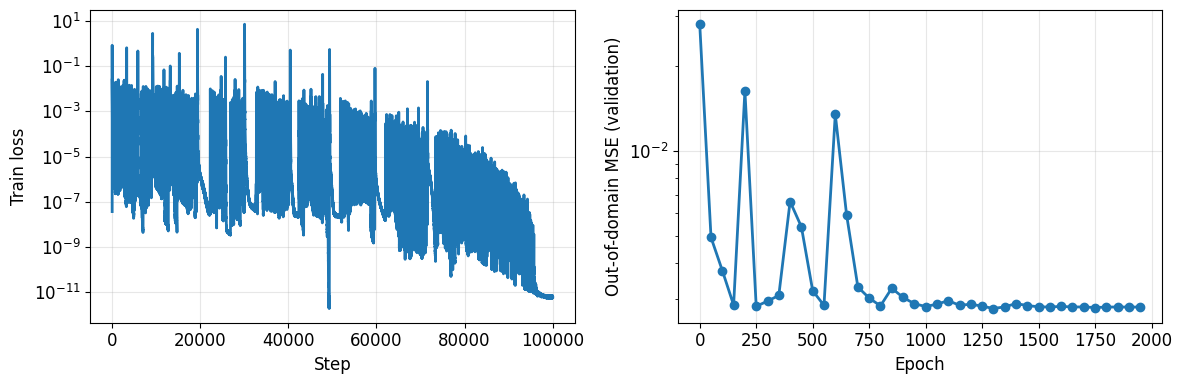

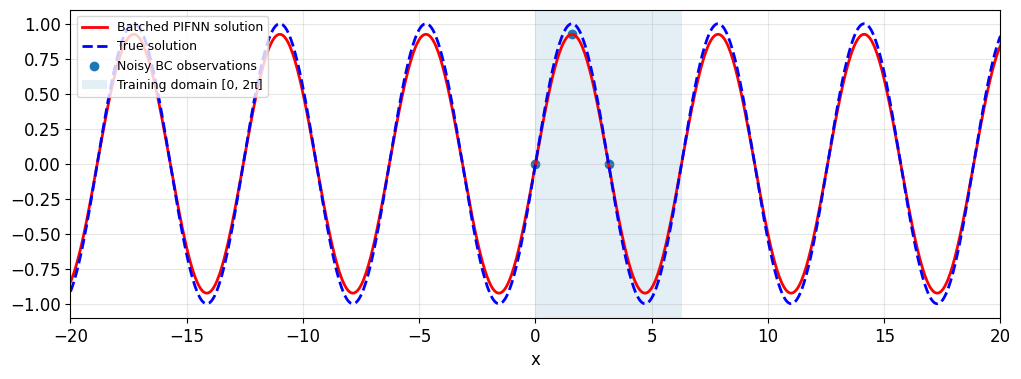

In [ ]:
# ======================================================
# Cell 4 — DataLoaders + Validation (PINN / PIFNN)
# ======================================================

import math
import torch
from torch.utils.data import Dataset, DataLoader
import time

t0 = time.time()
time_limit_sec = 60

# -----------------------------
# Collocation dataset (pool + resample)
# -----------------------------
class CollocationDataset(Dataset):
    def __init__(self, n_points, domain=(0.0, 2*math.pi), device=None):
        self.n_points = n_points
        self.a, self.b = domain
        self.device = device if device is not None else torch.device("cpu")
        self.resample()

    def resample(self):
        self.x = (self.a + (self.b - self.a) * torch.rand(self.n_points, 1, device=self.device))

    def __len__(self):
        return self.n_points

    def __getitem__(self, idx):
        return self.x[idx]

# -----------------------------
# BC dataset
# -----------------------------
class BCDataset(Dataset):
    def __init__(self, x_bc, y_bc):
        self.x_bc = x_bc
        self.y_bc = y_bc

    def __len__(self):
        return self.x_bc.shape[0]

    def __getitem__(self, idx):
        return self.x_bc[idx], self.y_bc[idx]

def cycle(loader):
    while True:
        for batch in loader:
            yield batch

# -----------------------------
# Fast validation (data MSE only)
# This is the right "generalization" plot you want outside training domain.
# -----------------------------
@torch.no_grad()
def eval_data_mse(model, x_val, y_val_true):
    model.eval()
    pred = model(x_val)
    return torch.mean((pred - y_val_true)**2).item()

# -----------------------------
# Training loop (FAST):
# - only do `steps_per_epoch` batches per epoch (instead of full pool)
# - validate every `val_every` epochs
# -----------------------------
def train_pinn_with_dataloaders_fast(
    model,
    ode_residual,
    bc_loader,
    col_loader,
    periodic_loss_fn=None,
    n_epochs=2000,
    steps_per_epoch=50,          # <<< KEY SPEED KNOB
    lr=0.04,
    bc_weight=10.0,
    use_scheduler=True,
    resample_collocation_each_epoch=True,
    x_val=None,
    y_val_true=None,
    val_every=50,
    print_every=200,
):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    if use_scheduler:
        scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs * steps_per_epoch)

    losses = []
    val_mse_log = []          # out-of-domain MSE (diagnostic)
    val_epochs = []           # epochs where we logged validation

    bc_iter = cycle(bc_loader)
    col_iter = cycle(col_loader)

    col_dataset = getattr(col_loader, "dataset", None)

    for epoch in range(n_epochs):
        model.train()

        if resample_collocation_each_epoch and hasattr(col_dataset, "resample"):
            col_dataset.resample()

        running = 0.0

        for step in range(steps_per_epoch):
            x_c = next(col_iter).to(device)
            x_c.requires_grad_(True)

            x_b, y_b = next(bc_iter)
            x_b = x_b.to(device)
            y_b = y_b.to(device)

            optimizer.zero_grad()

            # physics
            y_c = model(x_c)
            residual = ode_residual(model, x_c, y_c)
            physics_loss = torch.mean(residual**2)

            # BC (noisy y allowed)
            pred_b = model(x_b)
            bc_loss = torch.mean((pred_b - y_b)**2)

            # periodicity (optional)
            if periodic_loss_fn is not None:
                per_loss = torch.mean(periodic_loss_fn(model, x_c))
            else:
                per_loss = torch.tensor(0.0, device=device)

            loss = physics_loss + bc_weight * bc_loss + per_loss
            loss.backward()
            optimizer.step()

            if use_scheduler:
                scheduler.step()

            L = loss.item()
            losses.append(L)
            running += L

        # validation (fast, only data MSE)
        if (x_val is not None) and (y_val_true is not None) and (epoch % val_every == 0):
            vmse = eval_data_mse(model, x_val, y_val_true)
            val_mse_log.append(vmse)
            val_epochs.append(epoch)

        if epoch % print_every == 0:
            print(f"Epoch {epoch:5d} | loss/step {running/steps_per_epoch:.3e}"
                  + (f" | val MSE {val_mse_log[-1]:.3e}" if len(val_mse_log) else ""))

    return losses, (val_epochs, val_mse_log)

# ======================================================
# Build loaders + validation grid (uses x_bc, y_bc from Cell 3)
# ======================================================

# Collocation loader
n_collocation_pool = 20000
collocation_batch_size = 512

collocation_dataset = CollocationDataset(
    n_points=n_collocation_pool,
    domain=(0.0, float(2*torch.pi)),
    device=device
)

col_loader = DataLoader(
    collocation_dataset,
    batch_size=collocation_batch_size,
    shuffle=True,
    drop_last=True
)

# BC loader (small)
bc_dataset = BCDataset(x_bc, y_bc)
bc_loader = DataLoader(
    bc_dataset,
    batch_size=len(bc_dataset),   # full batch for BC (fast + stable)
    shuffle=True,
    drop_last=False
)

# Validation grid (outside training)
x_val = torch.linspace(-20.0, 20.0, 800, device=device).view(-1, 1)
y_val_true = torch.sin(x_val)

# ======================================================
# Train (FAST) + validation
# ======================================================
losses_batched, (val_epochs, val_mse) = train_pinn_with_dataloaders_fast(
    model=model,
    ode_residual=ode_residual,
    bc_loader=bc_loader,
    col_loader=col_loader,
    periodic_loss_fn=periodic_loss_fn,     # set None for plain PINN
    n_epochs=2000,
    steps_per_epoch=50,                    # <<< increase for more accuracy, decrease for speed
    lr=0.04,
    bc_weight=10.0,
    use_scheduler=True,
    resample_collocation_each_epoch=True,
    x_val=x_val,
    y_val_true=y_val_true,
    val_every=50,
    print_every=200
)

# ======================================================
# Plot: training loss + validation MSE
# ======================================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses_batched)
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Train loss")

plt.subplot(1, 2, 2)
plt.plot(val_epochs, val_mse, marker="o")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Out-of-domain MSE (validation)")
plt.tight_layout()
py.savefig("Batched_PIFNN_loss_and_validation.pdf")
plt.show()

# ======================================================
# Final prediction plot (same as before)
# ======================================================
x_eval = x_val
y_eval = model(x_eval).detach().cpu().numpy()

plt.figure(figsize=(12, 4))
plt.plot(x_eval.cpu().numpy(), y_eval, "r", label="Batched PIFNN solution")
plt.plot(x_eval.cpu().numpy(), torch.sin(x_eval).cpu().numpy(), "b--", label="True solution")
plt.scatter(x_bc.detach().cpu().numpy(), y_bc.detach().cpu().numpy(), label="Noisy BC observations")

train_left = 0.0
train_right = float(2 * torch.pi)
plt.axvspan(train_left, train_right, alpha=0.12, label="Training domain [0, 2π]")

plt.legend(loc="upper left", fontsize=9)
plt.xlabel("x")
plt.xlim(-20, 20)
py.savefig("Batched_PIFNN_prediction.pdf")
plt.show()


Example: Overfitting

In this experiment, the model has high capacity and is trained
on limited or noisy boundary data.
It fits the training constraints very well,
but generalizes poorly outside the training domain.

Device: cpu
Epoch     0 | data 5.342e-01 | phys 1.698e-02
Epoch  1000 | data 4.179e-02 | phys 4.549e-01
Epoch  2000 | data 3.873e-02 | phys 5.386e+00
Epoch  3000 | data 3.711e-02 | phys 7.342e+00
Epoch  4000 | data 3.614e-02 | phys 1.385e+01
Epoch  5000 | data 3.608e-02 | phys 1.154e+01
Epoch  6000 | data 3.560e-02 | phys 1.238e+01
Epoch  7000 | data 3.581e-02 | phys 1.071e+01


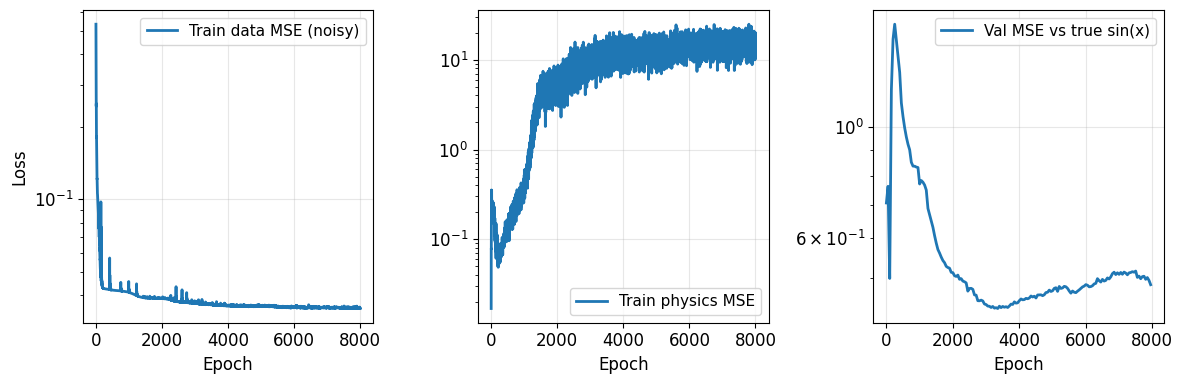

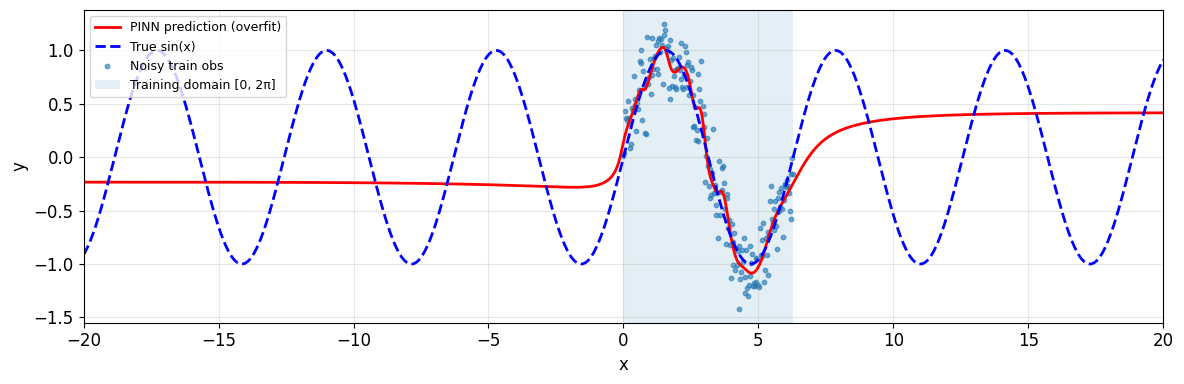

In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# -----------------------
# Reproducibility + device
# -----------------------
SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------
# Data: many noisy "observations" in training domain
# -----------------------
train_left, train_right = 0.0, float(2*torch.pi)
N_obs = 200                         # many obs points -> easy to overfit
noise_level = 0.20                  # big noise -> clearer overfitting

x_obs = torch.linspace(train_left, train_right, N_obs, device=device).view(-1, 1)
y_clean = torch.sin(x_obs)
y_obs = y_clean + noise_level * torch.randn_like(y_clean)  # noisy labels

# Validation domain (out-of-domain check)
x_val = torch.linspace(-20.0, 20.0, 800, device=device).view(-1, 1)
y_val_true = torch.sin(x_val)

# -----------------------
# Model (make it flexible so it can memorize noise)
# -----------------------
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        net = []
        for i in range(len(layers)-1):
            net.append(nn.Linear(layers[i], layers[i+1]))
            if i < len(layers)-2:
                net.append(nn.Tanh())
        self.model = nn.Sequential(*net)

    def forward(self, x):
        return self.model(x)

# Bigger network -> more capacity -> more overfit
model = PINN([1, 80, 80, 80, 1]).to(device)

# -----------------------
# Physics residual for sin: u'' + u = 0
# -----------------------
def ode_residual(model, x):
    x = x.requires_grad_(True)
    y = model(x)
    dy = torch.autograd.grad(y, x, torch.ones_like(y), create_graph=True)[0]
    d2y = torch.autograd.grad(dy, x, torch.ones_like(dy), create_graph=True)[0]
    return d2y + y

# -----------------------
# Training setup (INTENTIONALLY encourages overfitting)
# -----------------------
n_epochs = 8000
lr = 2e-3

# Key knobs to create overfitting:
lambda_data = 1.0      # coefficient of points loss
lambda_phys = 1e-4     #coefficient for physics loss
n_collocation = 128    # number of points where physics is enforced

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_data_losses = []
train_phys_losses = []
val_mse = []

val_every = 50

# -----------------------
# Train (no batching)
# -----------------------
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()

    # Collocation points (physics) in training domain
    x_c = (train_left + (train_right-train_left) * torch.rand(n_collocation, 1, device=device))

    # Loss terms
    pred_obs = model(x_obs)
    data_loss = torch.mean((pred_obs - y_obs)**2)

    r = ode_residual(model, x_c)
    phys_loss = torch.mean(r**2)

    loss = lambda_data * data_loss + lambda_phys * phys_loss
    loss.backward()
    optimizer.step()

    train_data_losses.append(data_loss.item())
    train_phys_losses.append(phys_loss.item())

    # Validation (true sin on wide domain)
    if epoch % val_every == 0:
        model.eval()
        with torch.no_grad():
            pred_val = model(x_val)
            vmse = torch.mean((pred_val - y_val_true)**2).item()
        val_mse.append(vmse)

    # occasional print
    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | data {data_loss.item():.3e} | phys {phys_loss.item():.3e}")

# -----------------------
# Plots: loss curves + overfit visualization
# -----------------------
model.eval()
with torch.no_grad():
    pred_train = model(x_obs).detach().cpu().numpy()
    pred_val = model(x_val).detach().cpu().numpy()

# 1) Loss curves
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(train_data_losses, label="Train data MSE (noisy)")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(train_phys_losses, label="Train physics MSE")
plt.yscale("log")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1,3,3)
plt.plot(np.arange(0, n_epochs, val_every), val_mse, label="Val MSE vs true sin(x)")
plt.yscale("log")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

# 2) Function plot: training region + out-of-domain
plt.figure(figsize=(12,4))
plt.plot(x_val.detach().cpu().numpy(), pred_val, "r", label="PINN prediction (overfit)")
plt.plot(x_val.detach().cpu().numpy(), y_val_true.detach().cpu().numpy(), "b--", label="True sin(x)")
plt.scatter(x_obs.detach().cpu().numpy(), y_obs.detach().cpu().numpy(), s=10, alpha=0.6, label="Noisy train obs")

plt.axvspan(train_left, train_right, alpha=0.12, label="Training domain [0, 2π]")
plt.xlim(-20, 20)
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()



Activation Function Comparison

This cell evaluates different activation functions
(e.g., Tanh, ReLU, Sigmoid, Sin, etc.)
to study their impact on convergence, smoothness,
and physics consistency in the PINN.

Training with ReLU
Training with LeakyReLU
Training with Tanh
Training with Sigmoid
Training with ELU
Training with GELU
Training with Swish
Training with Softplus
Training with Sine
Training with Cosine


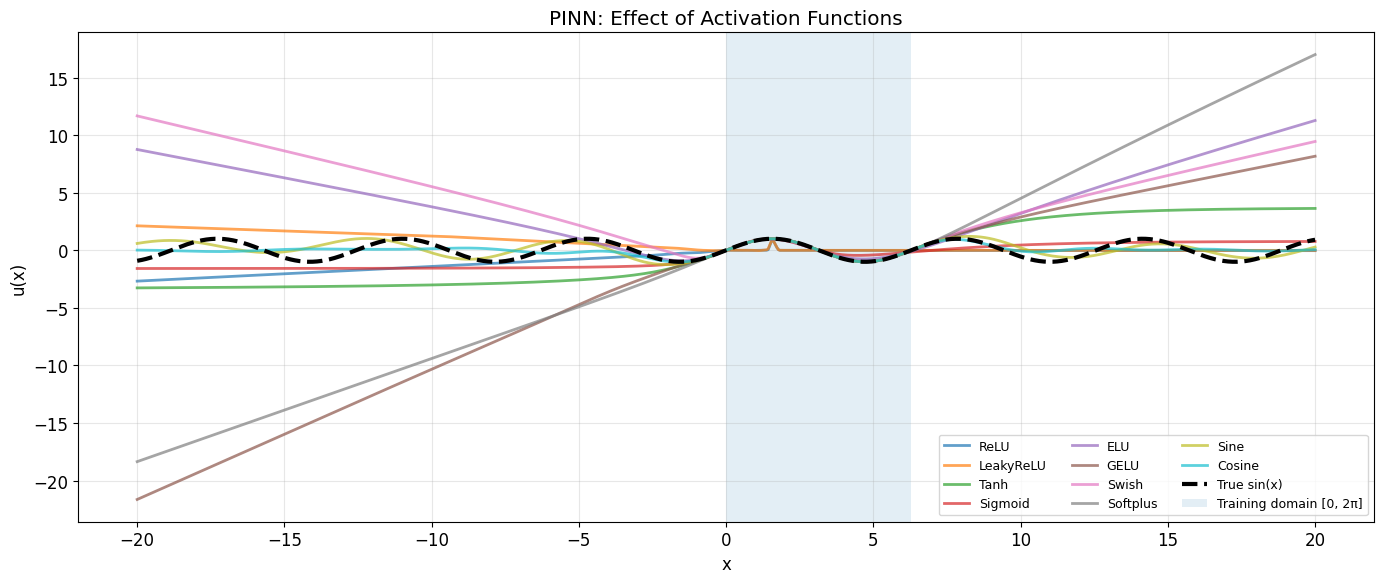

In [ ]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Setup
# -----------------------------
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_left, train_right = 0.0, float(2*torch.pi)
n_collocation = 500
n_epochs = 3000
lr = 1e-3
bc_weight = 10.0
phys_weight = 1.0

# validation domain
x_val = torch.linspace(-20, 20, 800, device=device).view(-1,1)
y_val_true = torch.sin(x_val)

# BCs
x_bc = torch.tensor([0.0, float(torch.pi/2), float(torch.pi)],
                    device=device).view(-1,1)
y_bc = torch.sin(x_bc)

# -----------------------------
# Physics residual (u'' + u = 0)
# -----------------------------
def ode_residual(model, x):
    # IMPORTANT: x must require grad for derivatives
    x = x.clone().detach().requires_grad_(True)
    y = model(x)

    dy = torch.autograd.grad(
        y, x, grad_outputs=torch.ones_like(y),
        create_graph=True, retain_graph=True
    )[0]

    d2y = torch.autograd.grad(
        dy, x, grad_outputs=torch.ones_like(dy),
        create_graph=True, retain_graph=True
    )[0]

    return d2y + y

# -----------------------------
# Activation factory
# -----------------------------
class Sine(nn.Module):
    def forward(self, x): return torch.sin(x)

class Cosine(nn.Module):
    def forward(self, x): return torch.cos(x)

def get_activation(name):
    table = {
        "ReLU": nn.ReLU(),
        "LeakyReLU": nn.LeakyReLU(0.1),
        "Tanh": nn.Tanh(),
        "Sigmoid": nn.Sigmoid(),
        "ELU": nn.ELU(),
        "GELU": nn.GELU(),
        "Swish": nn.SiLU(),
        "Softplus": nn.Softplus(),
        "Sine": Sine(),
        "Cosine": Cosine(),
        # "Identity": nn.Identity(),  # ❌ not suitable here (can break u'' autograd)
    }
    return table[name]

# -----------------------------
# PINN model
# -----------------------------
class PINN(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 40),
            activation,
            nn.Linear(40, 40),
            activation,
            nn.Linear(40, 1),
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------
# Train one activation
# -----------------------------
def train_activation(act_name):
    model = PINN(get_activation(act_name)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(n_epochs):
        opt.zero_grad()

        # collocation points in [0, 2π]
        x_c = train_left + (train_right - train_left) * torch.rand(n_collocation, 1, device=device)

        r = ode_residual(model, x_c)
        phys_loss = torch.mean(r**2)

        bc_loss = torch.mean((model(x_bc) - y_bc)**2)

        loss = phys_weight * phys_loss + bc_weight * bc_loss
        loss.backward()
        opt.step()

    with torch.no_grad():
        pred = model(x_val).detach().cpu().numpy()

    return pred

# -----------------------------
# Run experiment
# -----------------------------
activations = [
    "ReLU", "LeakyReLU", "Tanh", "Sigmoid", "ELU", "GELU",
    "Swish", "Softplus", "Sine", "Cosine"
]

results = {}
for act in activations:
    print(f"Training with {act}")
    results[act] = train_activation(act)

# -----------------------------
# Plot comparison
# -----------------------------
plt.figure(figsize=(14,6))

for act, pred in results.items():
    plt.plot(x_val.cpu().numpy(), pred, alpha=0.7, label=act)

plt.plot(x_val.cpu().numpy(),
         y_val_true.cpu().numpy(),
         "k--", linewidth=3, label="True sin(x)")

plt.axvspan(train_left, train_right, alpha=0.12, label="Training domain [0, 2π]")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("PINN: Effect of Activation Functions")
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()


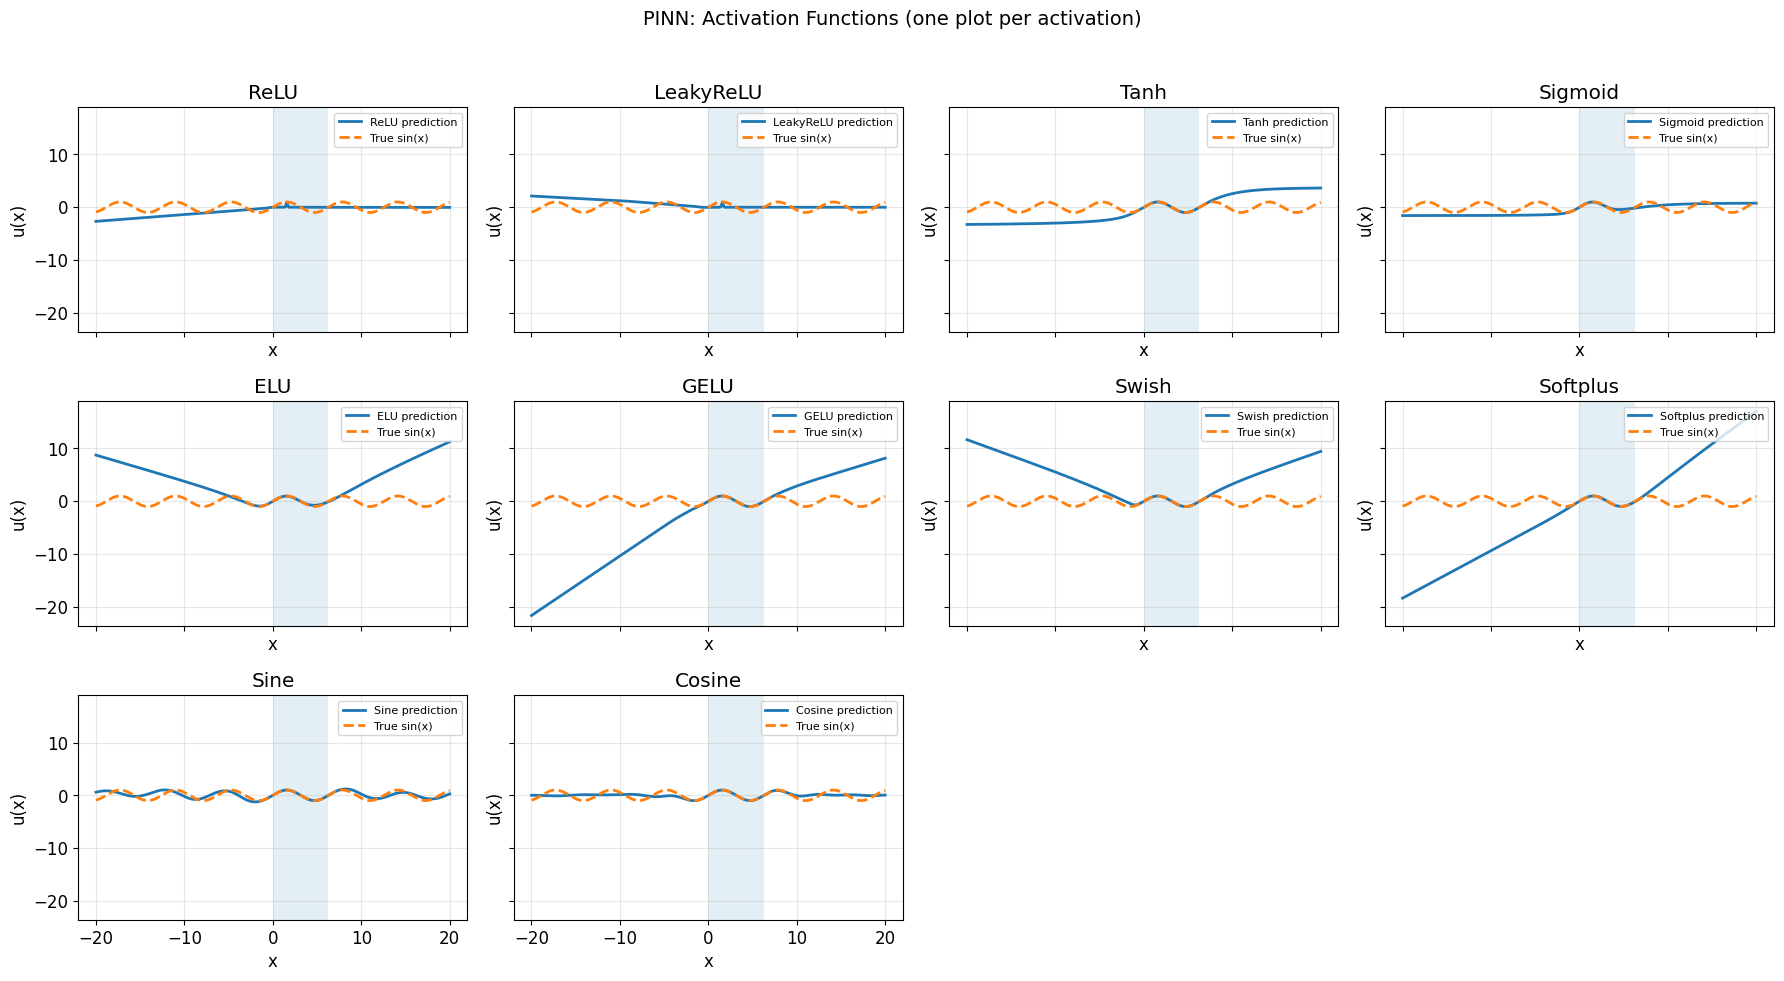

In [ ]:
# ==========================================================
# Plot each activation in its own subplot (grid of plots)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

x_np = x_val.detach().cpu().numpy().reshape(-1)
y_true_np = y_val_true.detach().cpu().numpy().reshape(-1)

acts = list(results.keys())
n = len(acts)

# Choose grid size automatically (close to square)
ncols = int(np.ceil(np.sqrt(n)))
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.2*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, act in enumerate(acts):
    ax = axes[i]
    pred = np.array(results[act]).reshape(-1)

    # prediction + truth
    ax.plot(x_np, pred, label=f"{act} prediction")
    ax.plot(x_np, y_true_np, "--", linewidth=2, label="True sin(x)")

    # training domain shading
    ax.axvspan(train_left, train_right, alpha=0.12)

    ax.set_title(act)
    ax.set_xlabel("x")
    ax.set_ylabel("u(x)")
    ax.grid(True, alpha=0.3)

    # keep legend small and consistent
    ax.legend(fontsize=8, loc="upper right")

# Turn off any empty subplots
for j in range(i+1, len(axes)):
    axes[j].axis("off")

fig.suptitle("PINN: Activation Functions (one plot per activation)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()
